In [ ]:
import torch
# Hyperparams
p1 = {
    '1_learning_rate': 0.0025, '1_hidden_size': 48, '1_dropout': 0.3,
    '1_quantum' : False, '1_num_head': 4, '1_Attention_N' : 2, '1_num_transf': 2, '1_mlp_size': 5, '1_patch_size': 4, '1_weight_decay': 1e-7, '1_attention_selection': 'none', 
    '1_selection_amount': 49, '1_RD': 1, '1_connectivity' : 'star' ,'1_entangle_method' : 'CRX', '1_special_cls' : 'none', '1_paralel': 1, '1_patience': -1, 
    '1_scheduler_factor': 0.985, '1_q_stride': 1, '1_ancilla' : 0, '1_channels_out' : list(range(4)), '1_augmentation_prob' : 0, '1_val_train_pond' : 1,
    '1_flatten_extra_channels' : False, '1_quanv_kernel_size' : 2
}

p2 = {
    'learning_rate': 0.0025, 'hidden_size': 48, 'dropout': 0.3,
    'quantum' : False, 'num_head': 4, 'Attention_N' : 2, 'num_transf': 2, 'mlp_size': 5, 'patch_size': 4, 'weight_decay': 1e-7, 'attention_selection': 'filter',
    'selection_amount': 49, 'RD': 1, 'special_cls' : 'none', 'paralel': 2, 'patience': -1, 'scheduler_factor': 0.985, 'q_stride': 1, 'augmentation_prob' : 0,
    'val_train_pond' : 1, 'len_channels_scaler' : 2
}

exp_config = {
    'channels_last'         : False,         # True if last dimension of datasets tensors match channels dimension
    'repeat_selector'       : False,         # True to train autoencoder each time for more variability
    'send_telegram'         : True,
    'num_experiments'       : 1,
    'num_classes'           : 7,
    'trained_selector_once' : False,
    'pixels'                : 28,
    'experiment_name'       : 'Resolution224/16x16patches/kernel3x3 Selformer',
    'experiment_id'         : 'final_stand/3x3/dropout_channels/extra_patches/4x4patches/concatenate_original',
    'variant'               : 'selformer',
    'B'                     : 2,
    'special_batch_for_data': False,
    'rewind_channels'       : False,
    'N1'                    : 1,
    'N2'                    : 20,
    'q_config'              : {'patchwise','none'},
    'device'                : torch.device("cuda:0" if torch.cuda.is_available() else "cpu"),
    'second_at_a_time'      : False,
    'augmenting'            : False,
    'concatenate_original'  : True
}

# Helper functions: 
def make_dropout(drop):
    return {'embedding_attn': drop, 'after_attn': drop, 'feedforward': drop, 'embedding_pos': drop}

visualizing_n = 1
concatenate_originals = True

Using downloaded and verified file: /home/carlosR/.medmnist/dermamnist.npz
Using downloaded and verified file: /home/carlosR/.medmnist/dermamnist.npz
Using downloaded and verified file: /home/carlosR/.medmnist/dermamnist.npz
Loaded MedMNIST dataset 'dermamnist' with image size 28x28 and 3 channels.
Using downloaded and verified file: /home/carlosR/.medmnist/dermamnist.npz
Started a MutliheadSelfAttention layer with embed_dim: 48 num_heads: 4 head_dim: 12
Started a MutliheadSelfAttention layer with embed_dim: 48 num_heads: 4 head_dim: 12
Shape of object: torch.Size([2, 3, 28, 28])


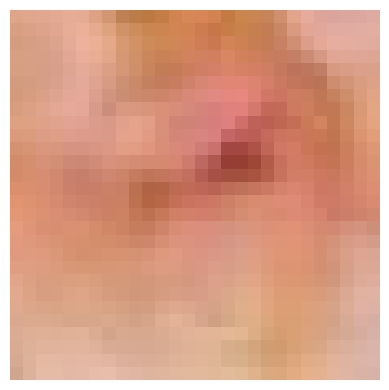

In [ ]:
import torch
import mi_quantum.data as data
from mi_quantum.quantum.quanvolution import QuantumConv2D
from mi_quantum.quantum.vit import VisionTransformer
import matplotlib.pyplot as plt
# Load data
notrans_train_dl, train_dl, val_dl, test_dl, shape = data.get_medmnist_dataloaders(
    pixel = exp_config['pixels'], data_flag='dermamnist', extra_tr_without_trans = True, batch_size=exp_config['B'], num_workers=4, pin_memory=True
)

def view_image_from_torch(tensor, i):
    for j in range(i):
        image_np = tensor[j,...].permute(1, 2, 0).numpy()

        plt.figure(figsize=(15, 4))
        plt.imshow(image_np)
        plt.axis('off')
        plt.tight_layout()
        plt.show()


model = VisionTransformer(
    img_size=28, num_channels=3, num_classes=exp_config['num_classes'],
    patch_size=p1['1_patch_size'], hidden_size= 3* p1['1_patch_size']**2, num_heads=p1['1_num_head'], Attention_N = p1['1_Attention_N'],
    num_transformer_blocks=p1['1_num_transf'], attention_selection= p1['1_attention_selection'], selection_amount = p1['1_selection_amount'], special_cls = p1['1_special_cls'], 
    mlp_hidden_size=p1['1_mlp_size'], quantum_mlp = False, dropout = make_dropout( p1['1_dropout']) , channels_last=exp_config['channels_last'], quantum_classification = False,
    paralel = p1['1_paralel'], RD = p1['1_RD'], q_stride = p1['1_q_stride'], connectivity = 'chain'
)

#notrans_train_dl.to(exp_config['device'])

first_batch = next(iter(notrans_train_dl))[0]

shape = first_batch.shape
B, C, H, W = shape
S, Q2, Q3, P = ( H // p1['1_patch_size'] )**2, 4, 9, p1['1_patch_size']
print(f"Shape of object: {shape}")
view_image_from_torch(first_batch, visualizing_n)


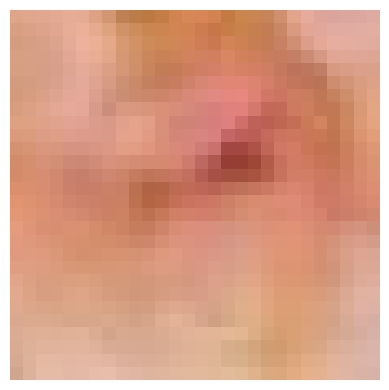

In [ ]:
aux_patches, selected_indices = model.get_patches_by_attention(x=first_batch, paralel_branch=0)
reconstructed = model.reconstruct_image_from_patches(aux_patches, selected_indices, original_image_shape= shape, quantum_channels=0, originals = True).squeeze().detach()
view_image_from_torch(reconstructed,visualizing_n)

In [ ]:
paddings = { 2 : { 'Up': 1, 'Down': 0, 'Left': 1, 'Right': 0 }, 3 : { 'Up': 1, 'Down': 1, 'Left': 1, 'Right': 1 } }

Quanvolution2x2 = QuantumConv2D(kernel_size = 2, stride = 1, padding = paddings[2],
                             channels_out = list(range(4)),ancilla= p1['1_ancilla'],graph = 'star',entangle_method = p1['1_entangle_method']
                            
)

Quanvolution3x3 = QuantumConv2D(kernel_size = 3, stride = 1, padding = paddings[3],
                             channels_out = list(range(9)), ancilla= p1['1_ancilla'], graph = 'king',entangle_method = p1['1_entangle_method']
                            
)

Quanvolution2x2.to(exp_config['device'])
Quanvolution3x3.to(exp_config['device'])
aux_patches = aux_patches.to(exp_config['device'])

aux_patches_processed2x2 = Quanvolution2x2(aux_patches.reshape(-1, C, p1['1_patch_size'], p1['1_patch_size'])).reshape(B, p1['1_selection_amount'] * Q2, C * P * P )
aux_patches_processed3x3 = Quanvolution3x3(aux_patches.reshape(-1, C, p1['1_patch_size'], p1['1_patch_size'])).reshape(B, p1['1_selection_amount'] * Q3, C * P * P )
if concatenate_originals:
    aux_patches_processed2x2 = torch.cat([aux_patches.reshape(B, p1['1_selection_amount'], C * P * P ), aux_patches_processed2x2 ], dim = 1)
    aux_patches_processed3x3 = torch.cat([aux_patches.reshape(B, p1['1_selection_amount'], C * P * P ), aux_patches_processed3x3 ], dim = 1)

reconstructed_processed2x2 = model.reconstruct_image_from_patches(aux_patches_processed2x2, selected_indices, original_image_shape = shape, quantum_channels= Q2, originals = concatenate_originals).squeeze().detach().to('cpu')
reconstructed_processed3x3 = model.reconstruct_image_from_patches(aux_patches_processed3x3, selected_indices, original_image_shape = shape, quantum_channels= Q3, originals = concatenate_originals).squeeze().detach().to('cpu')
reconstructed_processed2x2 = reconstructed_processed2x2.permute(0, 2, 3, 1, 4).reshape(B, C, H, (Q2+concatenate_originals)*W)
reconstructed_processed3x3 = reconstructed_processed3x3.permute(0, 2, 3, 1, 4).reshape(B, C, H, (Q3+concatenate_originals)*W)
view_image_from_torch(reconstructed_processed2x2, visualizing_n)
view_image_from_torch(reconstructed_processed3x3, visualizing_n)

RuntimeError: vmap: It looks like you're attempting to use a Tensor in some data-dependent control flow. We don't support that yet, please shout over at https://github.com/pytorch/functorch/issues/257 .

# Comparison between applying kernel patchwise or imagewise:

In [ ]:
processed_first_batch2x2 = Quanvolution2x2(first_batch)
processed_first_batch3x3 = Quanvolution3x3(first_batch)
if concatenate_originals:
    processed_first_batch2x2 = torch.cat([first_batch, processed_first_batch2x2], dim = 1)
    processed_first_batch3x3 = torch.cat([first_batch, processed_first_batch3x3], dim = 1)

processed_first_batch2x2 = processed_first_batch2x2.reshape(B, Q2+concatenate_originals, C, H, W).permute(0,2,3,1,4).reshape(B, C, H, (Q2+concatenate_originals)*W)
processed_first_batch3x3 = processed_first_batch3x3.reshape(B, Q3+concatenate_originals, C, H, W).permute(0,2,3,1,4).reshape(B, C, H, (Q3+concatenate_originals)*W)

# 2x2 Kernel, Imagewise vs Patchwise

Imagewise application of 2x2 kernel


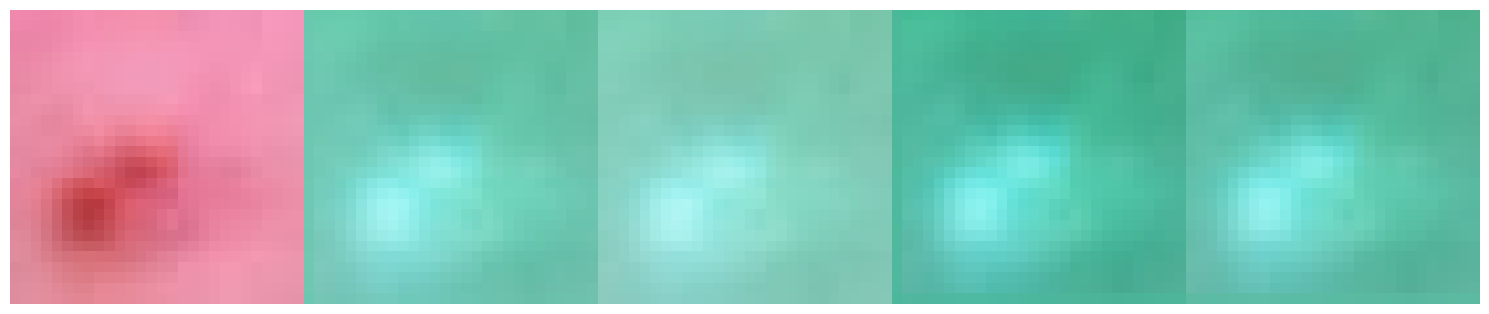

Patchwise application of 2x2 kernel


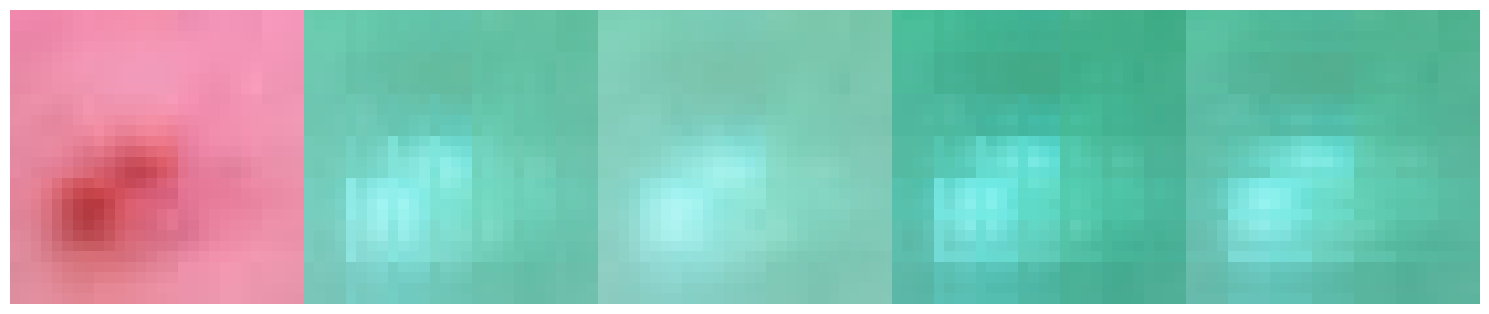

In [ ]:
print("Imagewise application of 2x2 kernel")
view_image_from_torch(processed_first_batch2x2, visualizing_n)
print("Patchwise application of 2x2 kernel")
view_image_from_torch(reconstructed_processed2x2, visualizing_n)

# 3x3 Kernel, Imagewise vs Patchwise

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.05671796..0.9764706].


Imagewise application of 2x2 kernel


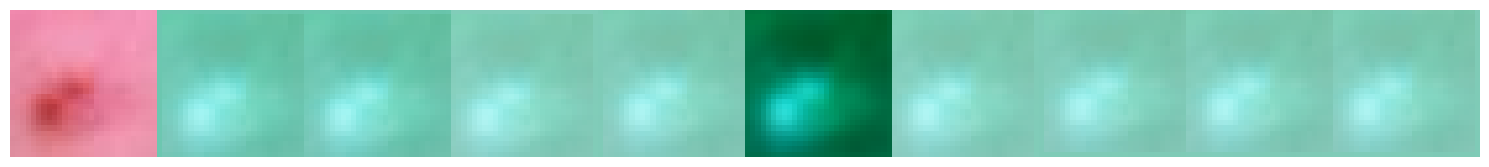

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.057064295..0.9764706].


Patchwise application of 3x3 kernel


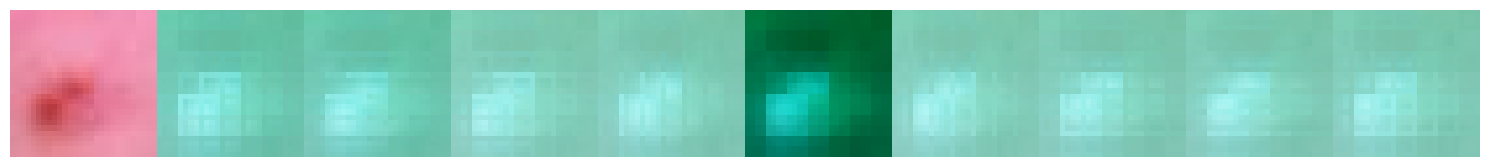

In [ ]:
print("Imagewise application of 2x2 kernel")
view_image_from_torch(processed_first_batch3x3, visualizing_n)
print("Patchwise application of 3x3 kernel")
view_image_from_torch(reconstructed_processed3x3, visualizing_n)